In [7]:
import time
import csv
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print(f"Đang sử dụng GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
else:
    print("Không tìm thấy GPU, sử dụng CPU")

Không tìm thấy GPU, sử dụng CPU


In [9]:
# ----- Cấu hình-----
latent_dim = 100
batch_size = 256 if torch.cuda.is_available() else 64
lr = 0.0004
epochs = 300

# For MNIST (grayscale)
nc = 1  # number of channels = 1 for MNIST
ngf = 64
ndf = 64

In [10]:
# WGAN-specific
n_critic = 5
clip_value = 0.01

# MNIST flatten size
img_size = 28 * 28

In [11]:
# ----- Dataset -----
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
train_loader = DataLoader(
    datasets.MNIST('.', train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True,
    pin_memory=True if device.type == 'cuda' else False
)

In [12]:
# weight init
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        if m.bias is not None: nn.init.constant_(m.bias.data, 0)
    if isinstance(m, nn.BatchNorm1d):
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# Generator: linear MLP
class Generator(nn.Module):
    def __init__(self, z_dim=latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(True),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(True),
            nn.Linear(256, img_size),
            nn.Tanh()
        )
    def forward(self, z):
        if z.dim() == 2:
            out = self.net(z)
        else:
            out = self.net(z.view(z.size(0), -1))
        return out.view(z.size(0), 1, 28, 28)

# Critic: linear MLP (no sigmoid)
class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(img_size, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(128, 1)   # raw score
        )
    def forward(self, img):
        return self.net(img).view(img.size(0), 1)

In [13]:
# ----- Khởi tạo mô hình và tối ưu hóa -----
generator = Generator().to(device)
critic = Critic().to(device)
generator.apply(init_weights)
critic.apply(init_weights)

# opt (kept lr)
optimizer_G = optim.AdamW(generator.parameters(), lr=lr)
optimizer_C = optim.AdamW(critic.parameters(), lr=lr)

In [14]:
def model_params_size_bytes(model):
    params = sum(p.numel() * p.element_size() for p in model.parameters())
    buffers = sum(b.numel() * b.element_size() for b in model.buffers())
    return params + buffers

def n_paramters_approx(n_MB: float):
    n_Bytes = int(n_MB * (1024**2))
    n_parameters = n_Bytes // 4 #Cho rằng các tham số có kiểu dữ liệu float32
    
    return int(n_parameters)

def bytes_to_mb(b):
    return b / (1024**2)

generator_parameters_size = bytes_to_mb(model_params_size_bytes(generator))
critic_parameters_size = bytes_to_mb(model_params_size_bytes(critic))
total_size = generator_parameters_size + critic_parameters_size
print(f"Numbers of parameters: {n_paramters_approx(total_size):,}")

print(f"Model size (MB):\n\tGenerator: {generator_parameters_size:.2f} (MB)\n\tCritic (Discriminator): {critic_parameters_size:.2f} (MB)\n\tTotal: {total_size:.2f} (MB)")


Numbers of parameters: 482,965
Model size (MB):
	Generator: 0.95 (MB)
	Critic (Discriminator): 0.89 (MB)
	Total: 1.84 (MB)


In [15]:
# Storage for metrics
history = {'epoch': 0, 'loss_C': [], 'loss_G': [], 'epoch_time_sec': []}

[Epoch 1/300] Loss_C: -0.7321, Loss_G: -2.1350, Time: 62.15s


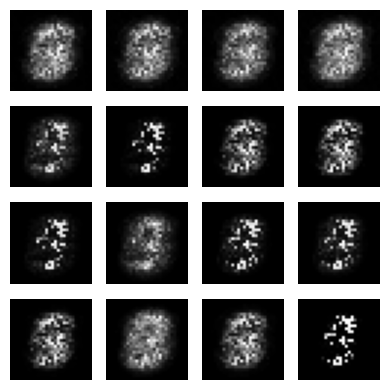

[Epoch 10/300] Loss_C: -0.1891, Loss_G: 0.0503, Time: 597.80s


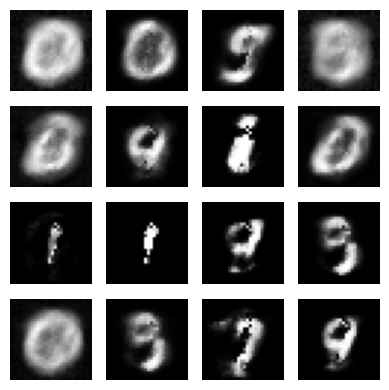

[Epoch 20/300] Loss_C: -0.1085, Loss_G: -0.2005, Time: 948.36s


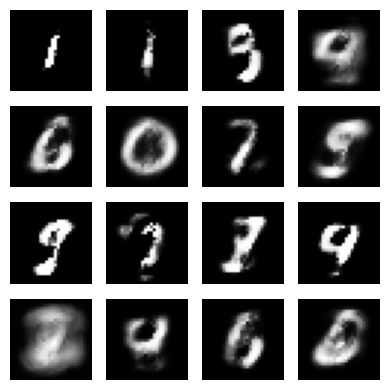

[Epoch 30/300] Loss_C: -0.0555, Loss_G: -0.1602, Time: 1358.80s


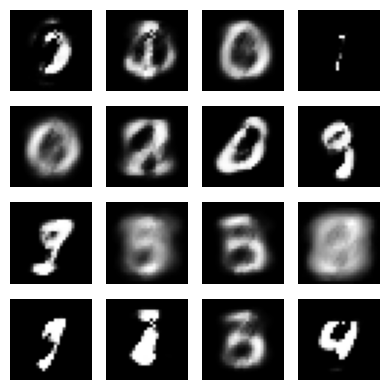

[Epoch 40/300] Loss_C: -0.0424, Loss_G: -0.4520, Time: 1830.15s


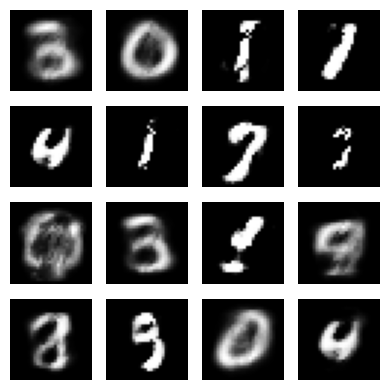

[Epoch 50/300] Loss_C: -0.0484, Loss_G: -0.6616, Time: 2317.78s


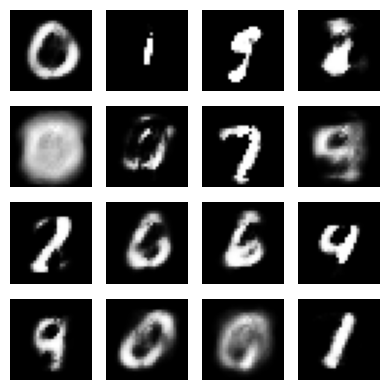

[Epoch 60/300] Loss_C: -0.0351, Loss_G: -0.3155, Time: 2808.70s


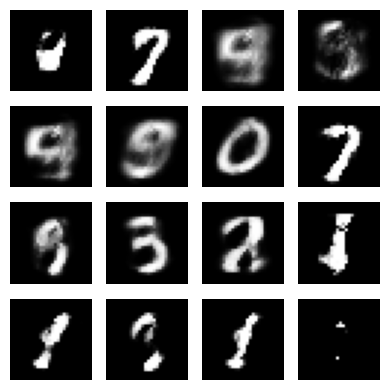

[Epoch 70/300] Loss_C: -0.0336, Loss_G: -0.5777, Time: 3301.53s


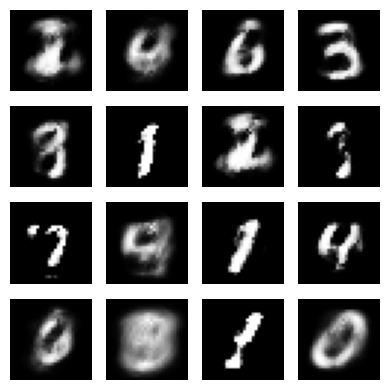

[Epoch 80/300] Loss_C: -0.0734, Loss_G: -1.8422, Time: 3697.68s


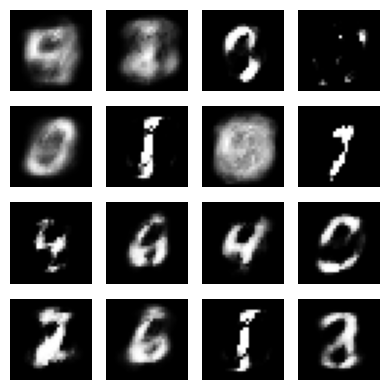

[Epoch 90/300] Loss_C: -0.0331, Loss_G: -0.1799, Time: 4085.66s


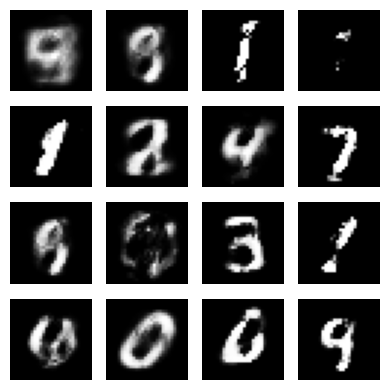

[Epoch 100/300] Loss_C: -0.0789, Loss_G: -2.0765, Time: 4475.86s


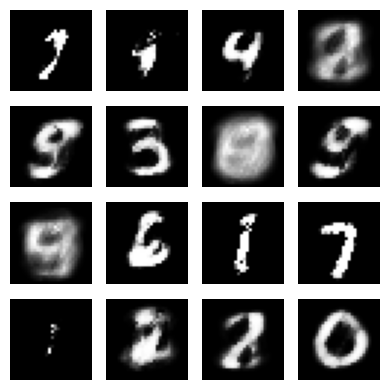

[Epoch 110/300] Loss_C: -0.0941, Loss_G: -0.8776, Time: 4875.85s


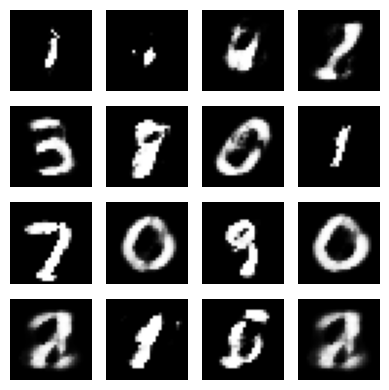

[Epoch 120/300] Loss_C: -0.0351, Loss_G: -1.4958, Time: 5272.57s


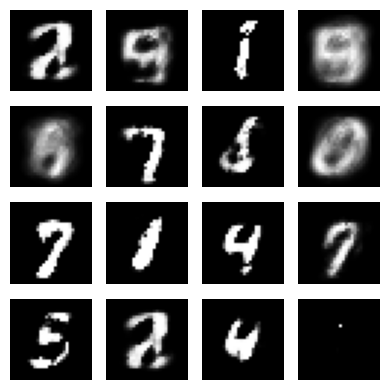

[Epoch 130/300] Loss_C: -0.0159, Loss_G: -0.1603, Time: 5669.80s


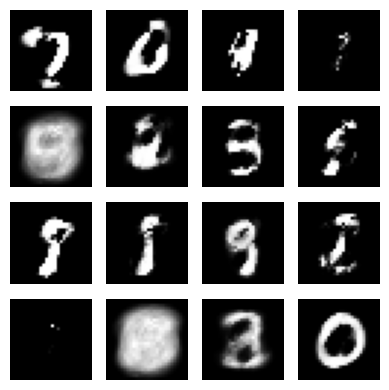

[Epoch 140/300] Loss_C: -0.0246, Loss_G: -0.7385, Time: 6065.45s


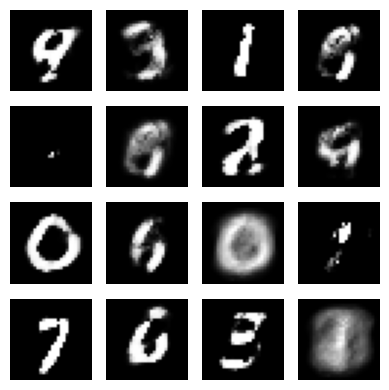

[Epoch 150/300] Loss_C: -0.0547, Loss_G: 1.8645, Time: 6462.12s


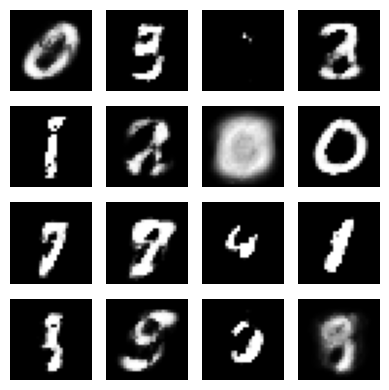

[Epoch 160/300] Loss_C: -0.0194, Loss_G: 0.2993, Time: 6856.91s


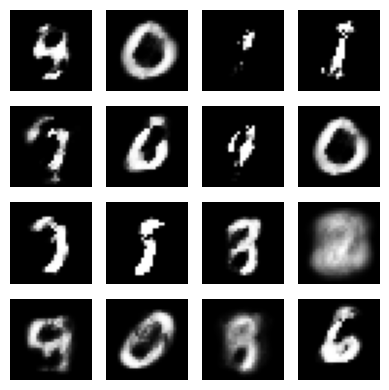

[Epoch 170/300] Loss_C: -0.0071, Loss_G: -0.3122, Time: 7208.81s


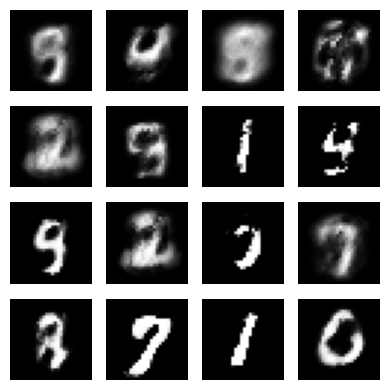

[Epoch 180/300] Loss_C: -0.0483, Loss_G: -1.5838, Time: 7602.66s


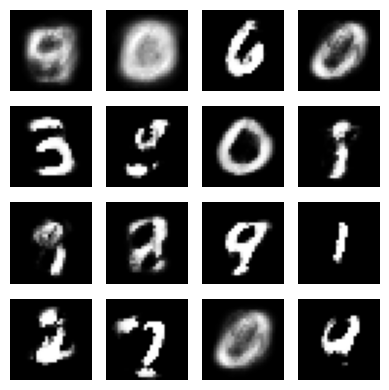

[Epoch 190/300] Loss_C: -0.0567, Loss_G: 0.9723, Time: 7915.41s


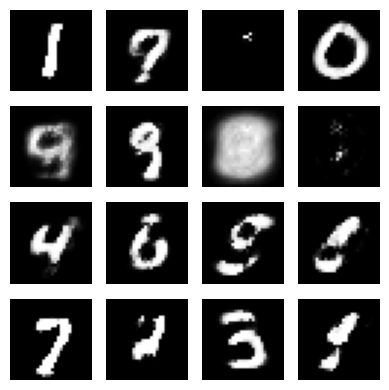

[Epoch 200/300] Loss_C: -0.0101, Loss_G: -0.2224, Time: 8230.18s


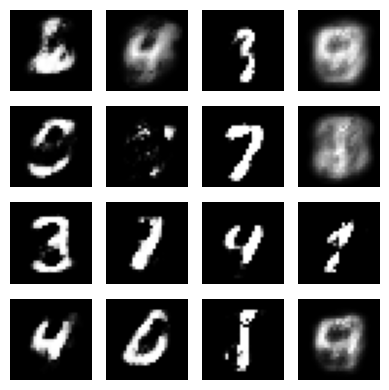

[Epoch 210/300] Loss_C: -0.0361, Loss_G: -2.0665, Time: 8592.76s


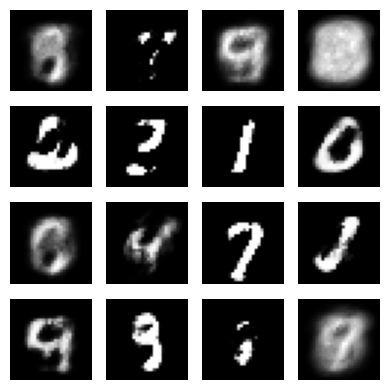

[Epoch 220/300] Loss_C: -0.0262, Loss_G: 0.4327, Time: 8930.71s


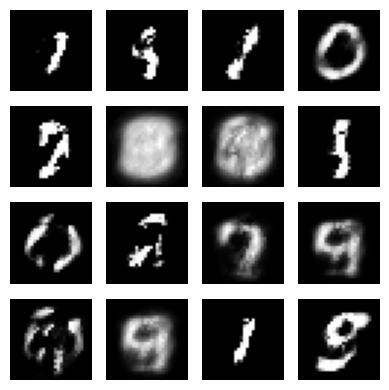

[Epoch 230/300] Loss_C: -0.0407, Loss_G: -1.6782, Time: 9303.66s


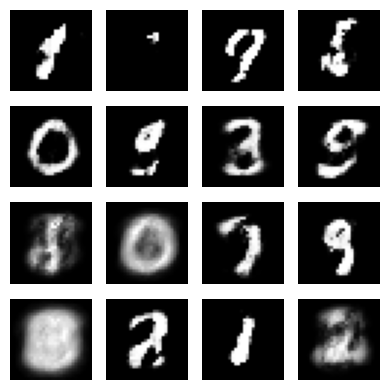

[Epoch 240/300] Loss_C: -0.0120, Loss_G: -0.3041, Time: 9669.67s


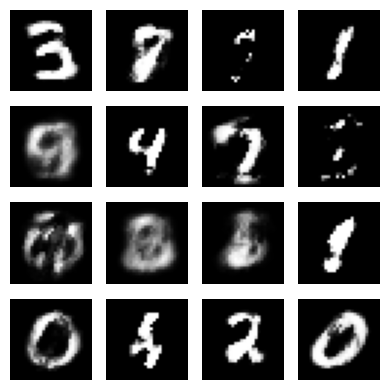

[Epoch 250/300] Loss_C: -0.0416, Loss_G: -2.0808, Time: 10033.36s


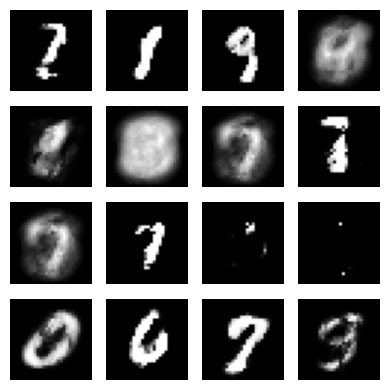

[Epoch 260/300] Loss_C: -0.0305, Loss_G: -0.7514, Time: 10399.70s


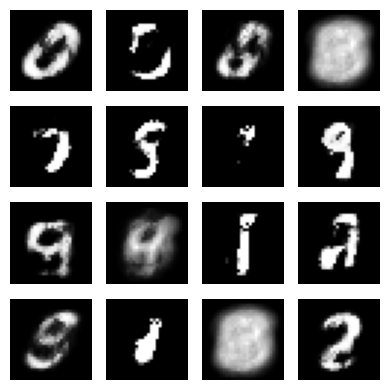

[Epoch 270/300] Loss_C: -0.0361, Loss_G: -1.4947, Time: 10767.75s


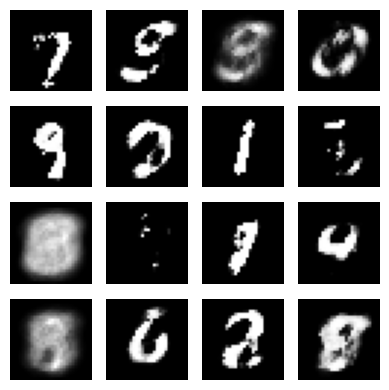

[Epoch 280/300] Loss_C: -0.0068, Loss_G: 0.1600, Time: 11140.31s


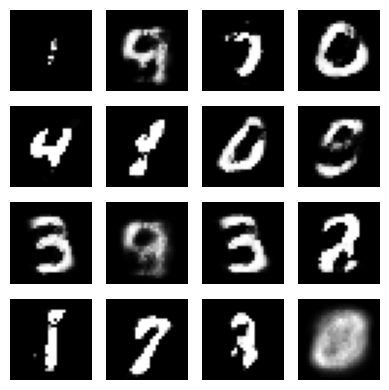

[Epoch 290/300] Loss_C: -0.0175, Loss_G: 0.3727, Time: 11510.70s


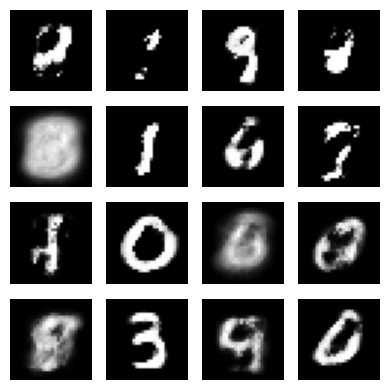

[Epoch 300/300] Loss_C: -0.0410, Loss_G: -1.2278, Time: 11823.85s


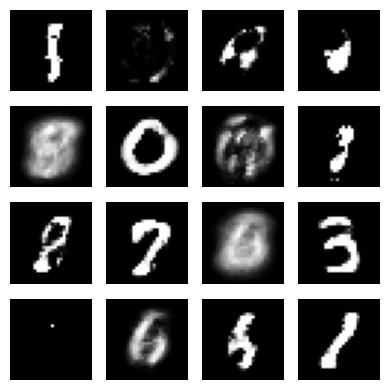

In [16]:
# training
t0 = time.perf_counter()
for epoch in range(1, epochs+1):
    epoch_loss_C = 0.0
    epoch_loss_G = 0.0

    for real_imgs, _ in train_loader:
        real_imgs = real_imgs.to(device, non_blocking=True)
        b = real_imgs.size(0)

        # update critic n_critic times
        for _ in range(n_critic):
            z = torch.randn(b, latent_dim, device=device)
            gen_imgs = generator(z).detach()

            optimizer_C.zero_grad()
            real_scores = critic(real_imgs)
            fake_scores = critic(gen_imgs)
            loss_C = fake_scores.mean() - real_scores.mean()  # minimize
            loss_C.backward()
            optimizer_C.step()

            # clip weights
            for p in critic.parameters():
                p.data.clamp_(-clip_value, clip_value)

            epoch_loss_C += loss_C.item()

        # generator step
        z = torch.randn(b, latent_dim, device=device)
        gen_imgs = generator(z)
        optimizer_G.zero_grad()
        fake_scores_for_G = critic(gen_imgs)
        loss_G = -fake_scores_for_G.mean()
        loss_G.backward()
        optimizer_G.step()
        epoch_loss_G += loss_G.item()

    num_batches = len(train_loader)
    avg_loss_C = epoch_loss_C / (num_batches * n_critic)
    avg_loss_G = epoch_loss_G / num_batches
    elapsed = time.perf_counter() - t0

    history['epoch'] += 1
    history['loss_C'].append(avg_loss_C)
    history['loss_G'].append(avg_loss_G)
    history['epoch_time_sec'].append(elapsed)

    if epoch == 1 or epoch % 10 == 0:
        print(f"[Epoch {epoch}/{epochs}] Loss_C: {avg_loss_C:.4f}, Loss_G: {avg_loss_G:.4f}, Time: {elapsed:.2f}s")
        with torch.no_grad():
            test_z = torch.randn(16, latent_dim, device=device)
            samples = generator(test_z).cpu()
        fig, axes = plt.subplots(4,4,figsize=(4,4))
        for img,ax in zip(samples, axes.flatten()):
            ax.imshow(img.squeeze()*0.5 + 0.5, cmap='gray'); ax.axis('off')
        plt.tight_layout(); plt.show()

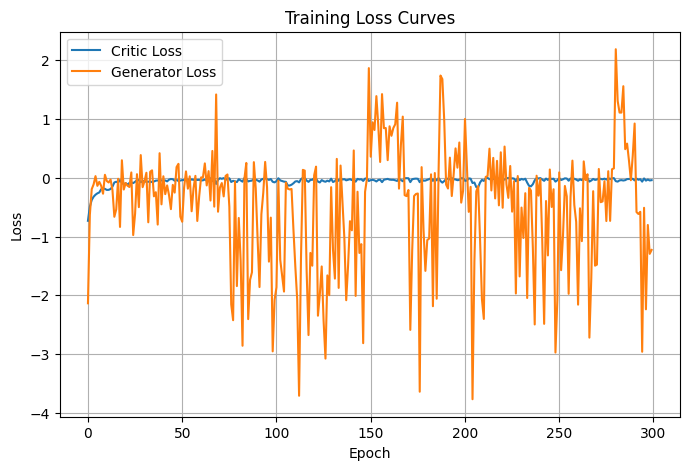

In [17]:
# Plot loss curves
plt.figure(figsize=(8, 5))
plt.plot(range(300), history['loss_C'], label='Critic Loss')
plt.plot(range(300), history['loss_G'], label='Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss Curves')
plt.grid(True)
plt.show() 

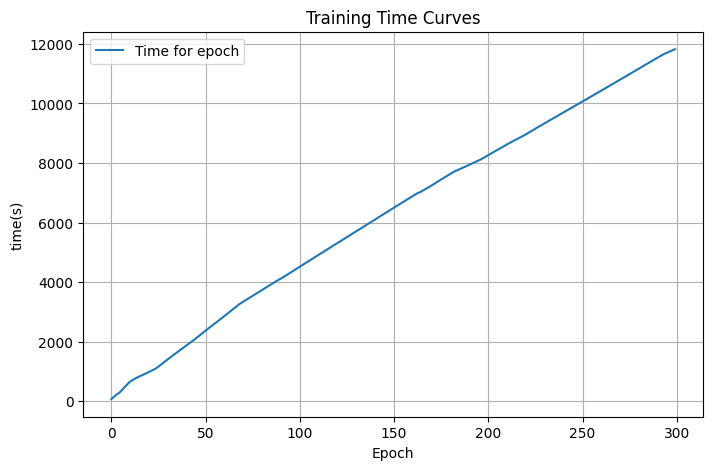

In [18]:
# Plot loss curves
plt.figure(figsize=(8, 5))
plt.plot(range(300), history['epoch_time_sec'], label='Time for epoch')
plt.xlabel('Epoch')
plt.ylabel('time(s)')
plt.legend()
plt.title('Training Time Curves')
plt.grid(True)
plt.show()

In [19]:
# Export to CSV
csv_file = 'WGAN_training_history.csv'
with open(csv_file, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['epoch', 'loss_C', 'loss_G', 'epoch_time_sec'])
    writer.writeheader()
    for e, ld, lg, t in zip(range(history['epoch']), history['loss_C'], history['loss_G'], history['epoch_time_sec']):
        writer.writerow({'epoch': e, 'loss_C': ld, 'loss_G': lg, 'epoch_time_sec': t})

print(f"Training history exported to {csv_file}")

Training history exported to WGAN_training_history.csv
